<a id='4'></a>
## 4. The Self-Consistent Loop: The Vlasov–Poisson System

### The Physical Narrative

The Vlasov equation derived in Section 3 describes how the distribution function $f(\mathbf{x}, \mathbf{v}, t)$ evolves once the electric field $\mathbf{E}$ is known. But the equation says nothing about where that field comes from. In an isolated plasma with no external source, the field is not imposed from outside — it is generated continuously by the very particles whose motion it governs. The problem is therefore self-referential: $\mathbf{E}$ shapes $f$, and $f$ determines $\mathbf{E}$. To make the problem tractable, the system must be **closed** — meaning we must supply the missing equation that relates the field back to the distribution. Poisson's equation provides exactly this closure.

The result is the **Vlasov–Poisson system**: a nonlinear, integro-differential feedback loop that is the foundational governing system for unmagnetized electrostatic plasma dynamics.

> **Analogy — The Flash Mob.** Imagine a plaza full of dancers. Each dancer listens to music and adjusts their movement accordingly — but the music itself is produced collectively by the noise of all their footsteps. Neither the choreography nor the music is primary. They are co-determined, moment by moment, in a continuous loop with no external conductor. This is precisely the structure of the Vlasov–Poisson system.

---

### 4.1 Assumptions of the Electrostatic Model

Before writing down the system, it is worth being precise about the physical regime we are targeting. The following assumptions are adopted, all inherited from the ordering established in 0 and the kinetic framework of 1–3.

**Assumption A1 — Electrostatic (unmagnetized) limit.** We neglect all magnetic perturbations generated by the plasma current. This is justified when the wave phase velocity $v_\phi = \omega / k$ satisfies $v_\phi \ll c$, which is well satisfied for Langmuir waves since $v_\phi \sim v_{Te} \ll c$. Under this limit, Faraday's law gives $\partial \mathbf{B}/\partial t \approx 0$, and the electric field is purely electrostatic:

$$
\mathbf{E} = -\nabla \phi. \tag{4.1}
$$

**Assumption A2 — Immobile ion background.** Ions are treated as a fixed, spatially uniform positive charge background of density $n_0$. This is justified by the mass ratio $m_i / m_e \gg 1$: on the timescale of electron plasma oscillations ($\omega_{pe}^{-1}$), ions barely move. Their contribution is therefore to maintain global charge neutrality, not to participate dynamically.

**Assumption A3 — Collisionless dynamics.** As established in §0, the plasma frequency greatly exceeds the collision frequency, $\omega_{pe} \gg \nu_{\mathrm{coll}}$. On the Langmuir oscillation timescale, inter-particle collisions are effectively frozen. This justified the Vlasov (zero right-hand side) equation in §§2–3, and it applies here as well.

**Assumption A4 — Non-relativistic electrons.** Electron velocities are assumed to satisfy $v \ll c$. This removes radiation reaction and relativistic corrections to the equations of motion.

**Assumption A5 — Single species.** We track only the electron distribution $f_e$. Because the ions are stationary, there is no separate ion kinetic equation to solve.

Together, these five assumptions reduce the full electromagnetic Boltzmann problem to a tractable electrostatic two-equation system.

---

### 4.2 The Vlasov–Poisson System

Under assumptions A1–A5, the governing equations are:

$$
\boxed{
\frac{\partial f_e}{\partial t}
+ \mathbf{v} \cdot \nabla_{\mathbf{x}} f_e
- \frac{e}{m_e} \mathbf{E} \cdot \nabla_{\mathbf{v}} f_e = 0
} \tag{4.2}
$$

$$
\boxed{
-\nabla^2 \phi = \frac{e}{\varepsilon_0}\!\left(n_0 - \int f_e \, d^3v\right), \qquad \mathbf{E} = -\nabla\phi
} \tag{4.3}
$$

**Variable anatomy:**
- $f_e(\mathbf{x}, \mathbf{v}, t)$ — electron distribution function $[\mathrm{s^3\,m^{-6}}]$.
- $\phi(\mathbf{x}, t)$ — electrostatic potential $[\mathrm{V}]$.
- $\mathbf{E}(\mathbf{x}, t) = -\nabla\phi$ — electric field $[\mathrm{V\,m^{-1}}]$; the force per unit charge.
- $n_0$ — uniform ion background density $[\mathrm{m^{-3}}]$; fixed throughout the simulation.
- $\int f_e \, d^3v = n_e(\mathbf{x}, t)$ — local electron number density $[\mathrm{m^{-3}}]$; this is the **zeroth moment** of the distribution. It collapses the full six-dimensional kinetic information into a three-dimensional spatial map.
- $\varepsilon_0$ — permittivity of free space $[\mathrm{F\,m^{-1}}]$.

**Provenance of Poisson's equation.** Equation (4.3) is simply Gauss's law, $\nabla \cdot \mathbf{E} = \rho / \varepsilon_0$, applied to the charge density $\rho = e(n_0 - n_e)$. The ion term $+e n_0$ represents the fixed positive background. The electron term $-e n_e = -e \int f_e \, d^3 v$ represents the local electron charge. On average $n_e = n_0$, so $\rho = 0$ and there is no mean field — only the perturbation field driven by fluctuations away from charge neutrality.

---

### 4.3 The Self-Consistent Loop: Logic and Structure

The two equations (4.2) and (4.3) constitute a closed dynamical system, but their coupling is intrinsically nonlinear: $\mathbf{E}$ depends on $f_e$ through the Poisson equation, and $f_e$ depends on $\mathbf{E}$ through the Vlasov equation. Neither can be solved independently.

The time evolution proceeds as the following cycle, repeated at each timestep $\Delta t$:

1. **$f_e \xrightarrow{\int d^3v} n_e(\mathbf{x},t)$** — Integrate the current distribution function over all velocities to obtain the local electron density at each spatial point.

2. **$n_e \xrightarrow{\text{Poisson}} \phi \xrightarrow{-\nabla} \mathbf{E}$** — Substitute $n_e$ into Poisson's equation and solve for the electrostatic potential $\phi$. Then differentiate to obtain the self-consistent field $\mathbf{E} = -\nabla\phi$.

3. **$\mathbf{E} \xrightarrow{\text{Vlasov}} f_e(t + \Delta t)$** — Use the electric field as the acceleration term in the Vlasov equation to advance the distribution function one timestep forward.

4. **Repeat.** The new $f_e$ generates a new $n_e$, which generates a new $\mathbf{E}$, which generates a new $f_e$, indefinitely. (The new positions create a new field, which creates new movement, indefinitely.)

This is the main "engine" of the simulation. We don't tell the particles where to go or give them a pre-set force from the outside. Instead, the particles create their own force just by moving around. When they bunch up in one spot, they create an electric field "hill." That field then immediately pushes those same particles toward the "valleys." As the particles move, the hills and valleys change, which then changes how the particles move next.

It’s a never-ending loop where the particles and the force are constantly reacting to each other in real-time.

---

### 4.4 The Maxwellian Equilibrium and the Poke

The Vlasov–Poisson system admits a trivial equilibrium: take $f_e = f_0(\mathbf{v})$ to be the spatially uniform Maxwellian from 1,

$$
f_0(\mathbf{v}) = n_0 \left(\frac{m_e}{2\pi k_B T_e}\right)^{3/2} \exp\!\left(-\frac{m_e |\mathbf{v}|^2}{2 k_B T_e}\right). \tag{4.4}
$$

In this state, $n_e = n_0$ everywhere, so the right-hand side of Poisson's equation vanishes, $\phi = 0$, and $\mathbf{E} = 0$. The Vlasov equation then reduces to $\partial f_0 / \partial t = 0$. The system is perfectly stationary: no forces, no evolution.

This is the "home base." The question that drives Sections 5 and 6 is what happens when the system is *perturbed*. We write

$$
f_e(\mathbf{x}, \mathbf{v}, t) = f_0(\mathbf{v}) + \delta f(\mathbf{x}, \mathbf{v}, t), \tag{4.5}
$$

where $|\delta f| \ll f_0$, and we call $\delta f$ the **perturbation** or "poke." Because $\delta f$ has spatial dependence, it induces a density fluctuation

$$
\delta n_e(\mathbf{x}, t) = \int \delta f \, d^3v \neq 0, \tag{4.6}
$$

which drives a non-zero $\mathbf{E}$ through Poisson's equation, which then feeds back on $f_e$ through the Vlasov equation. The loop is activated. Whether $\delta f$ grows, oscillates, or decays — this is the question of Langmuir wave theory and Landau damping, addressed in sections 5–6.

---

### 4.5 Conservation Properties of the Vlasov–Poisson System

The Vlasov–Poisson system is not merely a convenient model — it is a Hamiltonian system with conserved quantities that constrain the physics and serve as strict tests for numerical implementations.

**Particle number.** Integrating the Vlasov equation over phase space and using the divergence theorem,

$$
\frac{d}{dt} \int f_e \, d^3x \, d^3v = 0, \tag{4.7}
$$

so the total number of electrons is exactly conserved. In a simulation, deviations from particle conservation indicate truncation error or unphysical dissipation.

**Total energy.** The total energy of the system is the sum of kinetic and field energies:

$$
\mathcal{E} = \frac{m_e}{2} \int v^2 f_e \, d^3x \, d^3v + \frac{\varepsilon_0}{2} \int |\mathbf{E}|^2 \, d^3x. \tag{4.8}
$$

One can show, using the Vlasov and Poisson equations together, that $d\mathcal{E}/dt = 0$. Physically, this reflects the fact that Lorentz forces do no work on charges (in the electrostatic limit, the force is conservative) and energy merely exchanges between kinetic and field forms.

**Casimir invariants.** As shown in 3, for any smooth function $H$,

$$
\frac{d}{dt}\int H(f_e) \, d^3x \, d^3v = 0, \tag{4.9}
$$

by Liouville's theorem. The functional $-\int f_e \ln f_e \, d^3x \, d^3v$ (the fine-grained entropy) is therefore also conserved. A collisionless Vlasov plasma cannot irreversibly thermalize — the distribution function merely develops increasingly fine filamentary structure in velocity space, a process called **phase mixing**.

These conservation laws are not incidental — they represent the underlying symplectic structure of the Hamiltonian dynamics and are what make the Vlasov–Poisson system qualitatively different from a dissipative fluid model.


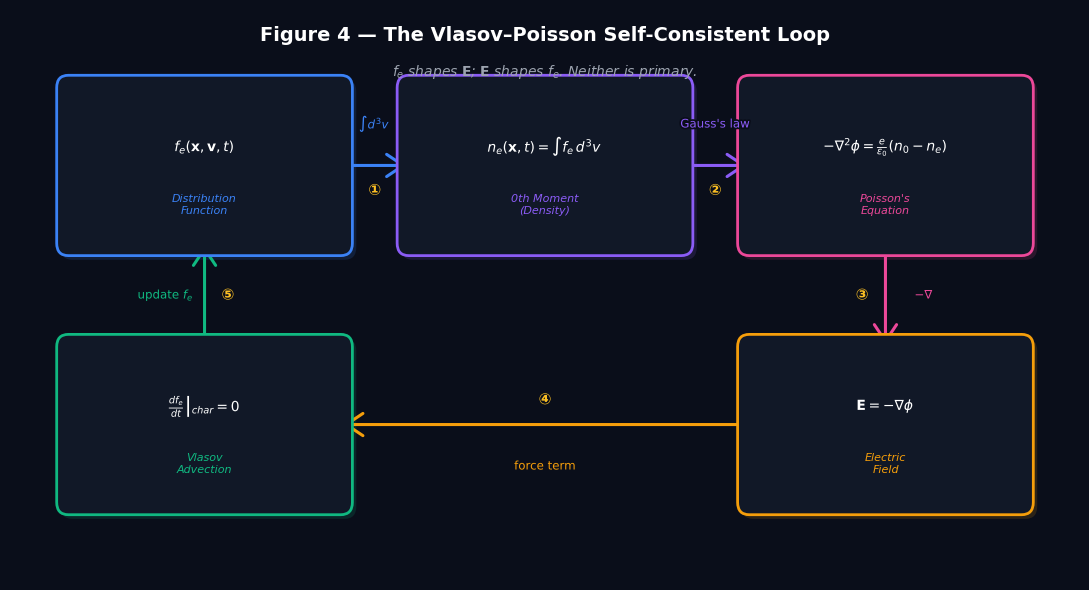

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# Ensure the plot displays correctly in a notebook environment
%matplotlib inline

# ── Setup Figure ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 5.5)
ax.axis('off')
ax.set_facecolor('#0a0e1a')
fig.patch.set_facecolor('#0a0e1a')

# ── Node definitions ─────────────────────────────────────────────────────────
# (cx, cy, top_label, bot_label, accent_color)
nodes = [
    (2.0,  4.0,
     r'$f_e(\mathbf{x},\mathbf{v},t)$',
     'Distribution\nFunction',
     '#3b82f6'),   # blue
    (5.5,  4.0,
     r'$n_e(\mathbf{x},t) = \int f_e\,d^3v$',
     '0th Moment\n(Density)',
     '#8b5cf6'),   # violet
    (9.0,  4.0,
     r'$-\nabla^2\phi = \frac{e}{\varepsilon_0}(n_0 - n_e)$',
     "Poisson's\nEquation",
     '#ec4899'),   # pink
    (9.0,  1.5,
     r'$\mathbf{E} = -\nabla\phi$',
     'Electric\nField',
     '#f59e0b'),   # amber
    (2.0,  1.5,
     r'$\left. \frac{df_e}{dt} \right|_{char} = 0$', # FIXED: Matplotlib compatible LaTeX
     'Vlasov\nAdvection',
     '#10b981'),   # emerald
]

box_w, box_h = 2.8, 1.5

def draw_node(ax, cx, cy, top_label, bot_label, color):
    # Glow shadow
    rect_shadow = mpatches.FancyBboxPatch(
        (cx - box_w/2 + 0.04, cy - box_h/2 - 0.04), box_w, box_h,
        boxstyle="round,pad=0.12",
        linewidth=0, edgecolor='none',
        facecolor=color, zorder=2, alpha=0.15)
    ax.add_patch(rect_shadow)
    
    # Main box
    rect = mpatches.FancyBboxPatch(
        (cx - box_w/2, cy - box_h/2), box_w, box_h,
        boxstyle="round,pad=0.12",
        linewidth=2, edgecolor=color,
        facecolor='#111827',
        zorder=3)
    ax.add_patch(rect)
    
    # Top equation label
    ax.text(cx, cy + 0.18, top_label,
            ha='center', va='center',
            fontsize=10, color='white', zorder=4,
            path_effects=[pe.withStroke(linewidth=2, foreground='#111827')])
    
    # Bottom descriptor label
    ax.text(cx, cy - 0.38, bot_label,
            ha='center', va='center',
            fontsize=8, color=color, zorder=4, linespacing=1.3,
            fontstyle='italic')

for cx, cy, tl, bl, col in nodes:
    draw_node(ax, cx, cy, tl, bl, col)

# ── Arrow definitions ────────────────────────────────────────────────────────
# (x0, y0, x1, y1, step_label, mid_label, color)
arrows = [
    # f -> density (top row)
    (2.0 + box_w/2, 4.0,   5.5 - box_w/2, 4.0,
     '①', r'$\int d^3v$',  '#3b82f6'),
    # density -> Poisson (top row)
    (5.5 + box_w/2, 4.0,   9.0 - box_w/2, 4.0,
     '②', "Gauss's law",  '#8b5cf6'),
    # Poisson -> E (right column)
    (9.0, 4.0 - box_h/2,   9.0, 1.5 + box_h/2,
     '③', r'$-\nabla$',    '#ec4899'),
    # E -> Vlasov (bottom row)
    (9.0 - box_w/2, 1.5,   2.0 + box_w/2, 1.5,
     '④', 'force term',    '#f59e0b'),
    # Vlasov -> f (left column)
    (2.0, 1.5 + box_h/2,   2.0, 4.0 - box_h/2,
     '⑤', r'update $f_e$', '#10b981'),
]

for x0, y0, x1, y1, step, lbl, col in arrows:
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->,head_width=0.4,head_length=0.6', 
                                color=col, lw=2.2,
                                mutation_scale=20,
                                connectionstyle='arc3,rad=0.0'),
                zorder=2)
    
    # Midpoint label (perpendicular offset)
    mx, my = (x0+x1)/2, (y0+y1)/2
    dx, dy = (x1-x0), (y1-y0)
    length = np.sqrt(dx**2 + dy**2)
    px, py = -dy/length * 0.4, dx/length * 0.4
    
    # Connection description
    ax.text(mx + px, my + py, lbl,
            ha='center', va='center', fontsize=8.5, color=col, zorder=5,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='#0a0e1a')])
    
    # Step number circle
    ax.text(mx - px*0.6, my - py*0.6, step,
            ha='center', va='center', fontsize=11,
            color='#fbbf24', fontweight='bold', zorder=6,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='#0a0e1a')])

# ── Titles ───────────────────────────────────────────────────────────────────
ax.text(5.5, 5.25, 'Figure 4 — The Vlasov–Poisson Self-Consistent Loop',
        ha='center', va='center', fontsize=14, fontweight='bold',
        color='white')
ax.text(5.5, 4.9, r'$f_e$ shapes $\mathbf{E}$; $\mathbf{E}$ shapes $f_e$. Neither is primary.',
        ha='center', va='center', fontsize=10, color='#9ca3af', style='italic')

plt.tight_layout()
plt.show()

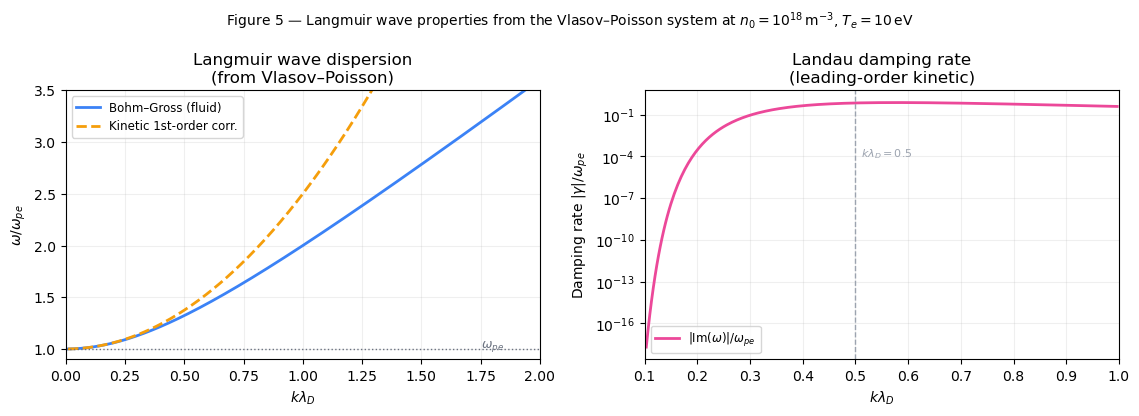

omega_pe = 5.641e+10 s^-1
lambda_D = 2.351e-05 m
v_Te     = 1.326e+06 m/s
At k*lD = 0.3:  omega/omega_pe = 1.1269  (Bohm-Gross)


In [3]:
# ── Figure 5: Langmuir dispersion relation from the Vlasov–Poisson system ─────
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (SI)
eps0 = 8.8541878128e-12
kB   = 1.380649e-23
e    = 1.602176634e-19
me   = 9.1093837015e-31

# Representative parameters
Te_eV = 10.0
Te    = Te_eV * e          # [J]
n0    = 1e18               # [m^{-3}]

omega_pe = np.sqrt(n0 * e**2 / (eps0 * me))
lambda_D = np.sqrt(eps0 * Te / (n0 * e**2))
vTe      = np.sqrt(Te / me)

k = np.linspace(0.01, 2.0, 600) / lambda_D   # wave-number [m^{-1}]
klD = k * lambda_D                            # dimensionless

# Bohm–Gross dispersion relation (fluid / warm plasma limit)
# omega^2 = omega_pe^2 (1 + 3 k^2 lambda_D^2)
omega_BG = omega_pe * np.sqrt(1.0 + 3.0 * klD**2)

# Kinetic correction: first-order thermal correction to Re(omega)
# omega ~ omega_pe (1 + 3/2 k^2 lambda_D^2)  for k lambda_D << 1
omega_kinetic = omega_pe * (1.0 + 1.5 * klD**2)

# Landau damping rate (leading order, valid for k lambda_D << 1)
# Im(omega) ~ -sqrt(pi/8) * omega_pe/(k lambda_D)^3 * exp(-1/(2k^2 lambda_D^2))
# only meaningful for small k lambda_D; clip to avoid overflow
with np.errstate(over='ignore', invalid='ignore'):
    exponent = -1.0 / (2.0 * klD**2 + 1e-12)
    gamma_L  = np.sqrt(np.pi / 8.0) * omega_pe / klD**3 * np.exp(exponent)
    gamma_L  = np.where(klD < 0.05, 0.0, np.abs(gamma_L))   # suppress tiny-k divergence

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# ── Left panel: dispersion relation ──────────────────────────────────────────
ax = axes[0]
ax.plot(klD, omega_BG   / omega_pe, lw=2,   label='Bohm–Gross (fluid)',  color='#3b82f6')
ax.plot(klD, omega_kinetic / omega_pe, lw=2, ls='--',
        label=r'Kinetic 1st-order corr.', color='#f59e0b')
ax.axhline(1.0, color='#6b7280', lw=1, ls=':')
ax.text(1.75, 1.02, r'$\omega_{pe}$', color='#6b7280', fontsize=9)
ax.set_xlabel(r'$k\lambda_D$')
ax.set_ylabel(r'$\omega / \omega_{pe}$')
ax.set_title('Langmuir wave dispersion\n(from Vlasov–Poisson)')
ax.legend(fontsize=8.5)
ax.set_xlim(0, 2); ax.set_ylim(0.9, 3.5)
ax.grid(alpha=0.2)

# ── Right panel: Landau damping rate ────────────────────────────────────────
ax2 = axes[1]
mask = (klD >= 0.1) & (klD <= 1.0)
ax2.semilogy(klD[mask], gamma_L[mask] / omega_pe, lw=2, color='#ec4899',
             label=r'$|\mathrm{Im}(\omega)|/\omega_{pe}$')
ax2.axvline(0.5, color='#9ca3af', lw=1, ls='--')
ax2.text(0.51, 1e-4, r'$k\lambda_D = 0.5$', color='#9ca3af', fontsize=8)
ax2.set_xlabel(r'$k\lambda_D$')
ax2.set_ylabel(r'Damping rate $|\gamma|/\omega_{pe}$')
ax2.set_title('Landau damping rate\n(leading-order kinetic)')
ax2.legend(fontsize=8.5)
ax2.set_xlim(0.1, 1.0)
ax2.grid(alpha=0.2)

fig.suptitle(
    r'Figure 5 — Langmuir wave properties from the Vlasov–Poisson system at '
    r'$n_0 = 10^{18}\,\mathrm{m^{-3}}$, $T_e = 10\,\mathrm{eV}$',
    fontsize=10)
fig.tight_layout()
plt.show()

print(f"omega_pe = {omega_pe:.3e} s^-1")
print(f"lambda_D = {lambda_D:.3e} m")
print(f"v_Te     = {vTe:.3e} m/s")
print(f"At k*lD = 0.3:  omega/omega_pe = {np.sqrt(1+3*0.3**2):.4f}  (Bohm-Gross)")


**Figure 5. Dispersion and damping from the Vlasov–Poisson system.**

The two panels confirm the physical predictions that emerge from the self-consistent loop.

*Left panel* — The Langmuir wave dispersion relation. For long wavelengths ($k\lambda_D \ll 1$), the wave frequency approaches $\omega_{pe}$ from above: the plasma oscillates at its natural frequency and thermal corrections are small. As $k\lambda_D$ increases, kinetic pressure stiffens the response and $\omega$ rises. The Bohm–Gross relation,

$$
\omega^2 = \omega_{pe}^2\!\left(1 + 3k^2\lambda_D^2\right), \tag{4.10}
$$

captures this in the fluid limit. The kinetic first-order correction shifts the curve slightly but preserves the qualitative structure. Both branches approach $\omega_{pe}$ as $k \to 0$, confirming that Langmuir waves are fundamentally tied to the plasma frequency set in §0.

*Right panel* — The Landau damping rate $|\mathrm{Im}(\omega)|$, the quintessential kinetic effect that is invisible to fluid models. For $k\lambda_D \lesssim 0.3$ the damping is exponentially small (long-wave oscillations decay negligibly), but it grows steeply as $k\lambda_D \to 1$, where the wave phase velocity approaches the thermal velocity and resonant wave–particle energy exchange becomes efficient. This is the signal that the velocity-space structure of $f_e$ — retained by the Vlasov equation but discarded by fluid truncation — is physically essential. The derivation of the damping rate will be tackled later on in part 6.
